# Preparing JUMP Cell Painting Dataset for μSplit
In this notebook we will do the following:
1. Load the Pilot dataset (cpg0000-jump-pilot) from an S3 bucket
2. Getting basic metadata about the dataset
3. Retrieving and visualizing image channels
4. Preparing images for μSplit analysis, using a subset to run the subsequent notebooks. 

We prepare images and combine the specified channels. The JUMP datasets are designed specifically to have 5 channels, with 6 dyes to reveal 8 cellular components, via a microscopy assay called Cell Painting. You can find more information about the datasets here: https://jump-cellpainting.broadinstitute.org/

The pilot dataset contains 6 batches (1 standard, 4 time points, 1 bleaching experiment) with 107 plates, 2.7M images, 38K wells with data. You can find more information about the pilot dataset here: https://github.com/jump-cellpainting/2024_Chandrasekaran_NatureMethods/tree/56845c7d4dc322652952783d91dae0ffef47829f


In [1]:
# import libraries 
import os
import numpy as np
import matplotlib.pyplot as plt
import tifffile
import boto3
from botocore import UNSIGNED
from botocore.config import Config
from PIL import Image
import io
from matplotlib import colors as mcolors
from typing import List, Dict, Optional, Tuple

Let's retrieve the data from the S3 bucket.

In [2]:
# S3 client setup for accessing public data
s3 = boto3.client('s3', config=Config(signature_version=UNSIGNED))
S3_BUCKET = "cellpainting-gallery"
S3_PREFIX = "cpg0000-jump-pilot/source_4/images/"
# Define channel mapping and information
CHANNELS = {
    "DNA": {"index": 5, "description": "Nucleus (Hoechst 33342)", "color": "blue"},
    "RNA": {"index": 3, "description": "Nucleoli, cytoplasmic RNA (SYTO 14)", "color": "yellow"},
    "ER": {"index": 4, "description": "Endoplasmic reticulum (Concanavalin A)", "color": "green"},
    "AGP": {"index": 2, "description": "Actin, Golgi, plasma membrane (Phalloidin/WGA)", "color": "orange"},
    "Mito": {"index": 1, "description": "Mitochondria (MitoTracker Deep Red)", "color": "red"}
}

# Batch information
BATCHES = [
    "2020_11_04_CPJUMP1",
    "2020_11_18_CPJUMP1_TimepointDay1",
    "2020_11_19_TimepointDay4",
    "2020_12_02_CPJUMP1_2WeeksTimePoint",
    "2020_12_07_CPJUMP1_4WeeksTimePoint",
    "2020_12_08_CPJUMP1_Bleaching"
]

In [3]:
# some functions

def get_plates_in_batch(batch: str) -> List[str]:
    """Get list of plates in a specific batch"""
    prefix = f"{S3_PREFIX}{batch}/images/"
    response = s3.list_objects_v2(Bucket=S3_BUCKET, Prefix=prefix, Delimiter='/')
    plates = [prefix['Prefix'].split('/')[-2] for prefix in response.get('CommonPrefixes', [])]
    return plates

def get_s3_image_path(batch: str, plate: str, row: int, col: int, site: int, channel: int) -> str:
    """Generate S3 path for a specific image"""
    row_str = f"r{row:02d}"
    col_str = f"c{col:02d}"
    site_str = f"f{site:02d}"
    channel_str = f"ch{channel:01d}"
    
    path = f"{S3_PREFIX}{batch}/images/{plate}/Images/{row_str}{col_str}{site_str}p01-{channel_str}sk1fk1fl1.tiff"
    return path

def get_image(batch: str, plate: str, row: int, col: int, site: int, channel: int) -> Optional[np.ndarray]:
    """Download and return image from S3"""
    try:
        path = get_s3_image_path(batch, plate, row, col, site, channel)
        response = s3.get_object(Bucket=S3_BUCKET, Key=path)
        img = tifffile.imread(io.BytesIO(response['Body'].read()))
        return img
    except Exception as e:
        print(f"Error downloading image: {e}")
        return None

def display_all_channels(batch: str, plate: str, row: int, col: int, site: int) -> Tuple[Dict[str, np.ndarray], plt.Figure]:
    """Display all channels with appropriate colors and return the images"""
    fig, axes = plt.subplots(1, len(CHANNELS) + 1, figsize=(24, 4))
    images = {}
    
    # Display individual channels
    for i, (channel_name, info) in enumerate(CHANNELS.items()):
        img = get_image(batch, plate, row, col, site, info["index"])
        if img is not None:
            # Save image to dictionary
            images[channel_name] = img
            
            # Normalize for display
            img_norm = img.astype(float) / img.max()
            
            # Create custom colormap for this channel
            cmap = mcolors.LinearSegmentedColormap.from_list(
                f"custom_{info['color']}", ["black", info['color']]
            )
            
            axes[i].imshow(img_norm, cmap=cmap)
            axes[i].set_title(f"{channel_name}: {info['description']}")
            axes[i].axis('off')
    
    # Create colorful composite image if all channels were loaded
    if len(images) == 5:
        # Create multichannel composite
        composite = np.zeros((*list(images.values())[0].shape, 3))
        
        # Add each channel with appropriate color weighting
        composite[..., 2] = images["DNA"].astype(float) / images["DNA"].max()  # Blue
        composite[..., 1] = 0.7 * images["ER"].astype(float) / images["ER"].max() + \
                           0.3 * images["RNA"].astype(float) / images["RNA"].max()  # Green+Yellow
        composite[..., 0] = 0.7 * images["Mito"].astype(float) / images["Mito"].max() + \
                           0.3 * images["AGP"].astype(float) / images["AGP"].max()  # Red+Orange
        
        # Display composite
        axes[5].imshow(np.clip(composite, 0, 1))
        axes[5].set_title("5-Channel Composite")
        axes[5].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    return images, fig

def combine_channels_for_microsplit(
    images: Dict[str, np.ndarray],
    channels_to_combine: List[str] = ["DNA", "Mito"],
    weights: Optional[List[float]] = None,
    normalize: bool = False
) -> Tuple[np.ndarray, Dict]:
    """
    Combine multiple channels into a single image for μSplit input
    
    Parameters
    ----------
    images: dict
        Dictionary containing channel names and their corresponding images
    channels_to_combine: list
        List of channel names to combine
    weights: list or None
        Optional weights for each channel
    normalize: bool
        Whether to normalize intensity values
        
    Returns
    --------
    combined_img: numpy.ndarray
        Combined image
    stats: dict
        Statistics about the combination process
    """
    processed_images = {}
    
    # Process each channel
    for channel in channels_to_combine:
        if channel not in images:
            raise ValueError(f"Channel '{channel}' not found in images")
        
        img = images[channel].astype(np.float32)
        
        if normalize:
            # Avoid division by zero
            img_min, img_max = img.min(), img.max()
            if img_max > img_min:
                img = (img - img_min) / (img_max - img_min)
                
        processed_images[channel] = img
    
    # Apply weights for combining
    if weights is None:
        weights = [1.0 / len(channels_to_combine)] * len(channels_to_combine)
        
    if len(weights) != len(channels_to_combine):
        raise ValueError(f"Number of weights ({len(weights)}) must match number of channels ({len(channels_to_combine)})")
    
    # Create combined image
    combined_img = np.zeros_like(processed_images[channels_to_combine[0]])
    for channel, weight in zip(channels_to_combine, weights):
        combined_img += processed_images[channel] * weight
    
    # Collect statistics
    stats = {
        "min_val": combined_img.min(),
        "max_val": combined_img.max(),
        "mean_val": combined_img.mean(),
        "std_val": combined_img.std()
    }
    
    return combined_img, stats

def create_microsplit_dataset(
    batch: str,
    plate: str,
    output_dir: str = "microsplit_pilot_dataset",
    num_samples: int = 10,
    channels_to_combine: List[List[str]] = None,
    normalize: bool = False
):
    """
    Create a small dataset for μSplit from the pilot data
    
    Parameters
    ----------
    batch: str
        Batch name to use
    plate: str
        Plate name to use
    output_dir: str
        Directory to save the dataset
    num_samples: int
        Number of image samples to collect
    channels_to_combine: list of lists
        List of channel combinations to create
    normalize: bool
        Whether to normalize intensity values
    """
    if channels_to_combine is None:
        # Default: create all 5 channels dataset
        channels_to_combine = [list(CHANNELS.keys())]
    
    # Create output directories
    os.makedirs(output_dir, exist_ok=True)
    os.makedirs(os.path.join(output_dir, "combined"), exist_ok=True)
    
    for channel_list in channels_to_combine:
        for channel in channel_list:
            os.makedirs(os.path.join(output_dir, channel), exist_ok=True)
    
    # Track experiment information
    experiment_info = {
        "combined_images": [],
        "original_images": {},
        "metadata": []
    }
    
    for channel_list in channels_to_combine:
        for channel in channel_list:
            experiment_info["original_images"][channel] = []
    
    # Select random wells and sites
    np.random.seed(42)  # For reproducibility
    
    # Generate random positions ensuring diversity
    positions = []
    for _ in range(num_samples):
        row = np.random.randint(1, 16)
        col = np.random.randint(1, 24)
        site = np.random.randint(1, 9)
        positions.append((row, col, site))
    
    # Process each position
    for i, (row, col, site) in enumerate(positions):
        print(f"Processing sample {i+1}/{num_samples}: Well {chr(64+row)}{col:02d}, Site {site}")
        
        # Get images for all channels
        all_images, _ = display_all_channels(batch, plate, row, col, site)
        
        # Process each channel combination
        for channel_list in channels_to_combine:
            channel_str = "_".join(channel_list)
            
            # Combine channels
            try:
                combined_img, stats = combine_channels_for_microsplit(
                    all_images,
                    channels_to_combine=channel_list,
                    normalize=normalize
                )
                
                # Save combined image
                combined_filename = f"img_{i:05d}_combined.tif"
                combined_path = os.path.join(output_dir, "combined", combined_filename)
                tifffile.imwrite(combined_path, combined_img)
                experiment_info["combined_images"].append(combined_path)
                
                # Save individual channel images
                for channel in channel_list:
                    channel_filename = f"img_{i:05d}_{channel}.tif"
                    channel_path = os.path.join(output_dir, channel, channel_filename)
                    tifffile.imwrite(channel_path, all_images[channel])
                    experiment_info["original_images"][channel].append(channel_path)
                
                # Store metadata
                experiment_info["metadata"].append({
                    "image_id": i,
                    "batch": batch,
                    "plate": plate,
                    "well": f"{chr(64+row)}{col:02d}",
                    "site": site,
                    "combined_channels": channel_list,
                    "normalized": normalize,
                    "stats": stats
                })
                
            except Exception as e:
                print(f"Error processing image {i}: {e}")
                continue
    
    print(f"Dataset created with {len(experiment_info['metadata'])} images")
    print(f" - Combined images saved to: {os.path.join(output_dir, 'combined')}")
    for channel in CHANNELS:
        if os.path.exists(os.path.join(output_dir, channel)):
            print(f" - {channel} channel images saved to: {os.path.join(output_dir, channel)}")
    
    import pandas as pd
    
    # Create DataFrame from metadata
    metadata_df = pd.DataFrame(experiment_info["metadata"])
    
    # Export to CSV
    metadata_csv_path = os.path.join(output_dir, "metadata.csv")
    metadata_df.to_csv(metadata_csv_path, index=False)
    print(f" - Metadata saved to: {metadata_csv_path}")
    
    return experiment_info



Let's create a dataset using the first batch 2020_11_04_CPJUMP1. We will combine all 5 channels for this experiment. 

Available batches:
 - 2020_11_04_CPJUMP1: 51 plates
   First plate: BR00116991__2020-11-05T19_51_35-Measurement1
 - 2020_11_18_CPJUMP1_TimepointDay1: 8 plates
   First plate: BR00117006__2020-11-03T19_45_39-Measurement1
 - 2020_11_19_TimepointDay4: 8 plates
   First plate: BR00117006__2020-11-07T13_09_23-Measurement2
 - 2020_12_02_CPJUMP1_2WeeksTimePoint: 8 plates
   First plate: BR00117006__2020-11-16T18_47_45-Measurement3
 - 2020_12_07_CPJUMP1_4WeeksTimePoint: 8 plates
   First plate: BR00117006__2020-11-30T20_43_44-Measurement2
 - 2020_12_08_CPJUMP1_Bleaching: 24 plates
   First plate: BR00116991A__2020-11-11T18_34_27-Measurement1

Creating dataset from batch 2020_11_04_CPJUMP1, plate BR00116991__2020-11-05T19_51_35-Measurement1
Processing sample 1/10: Well G20, Site 5


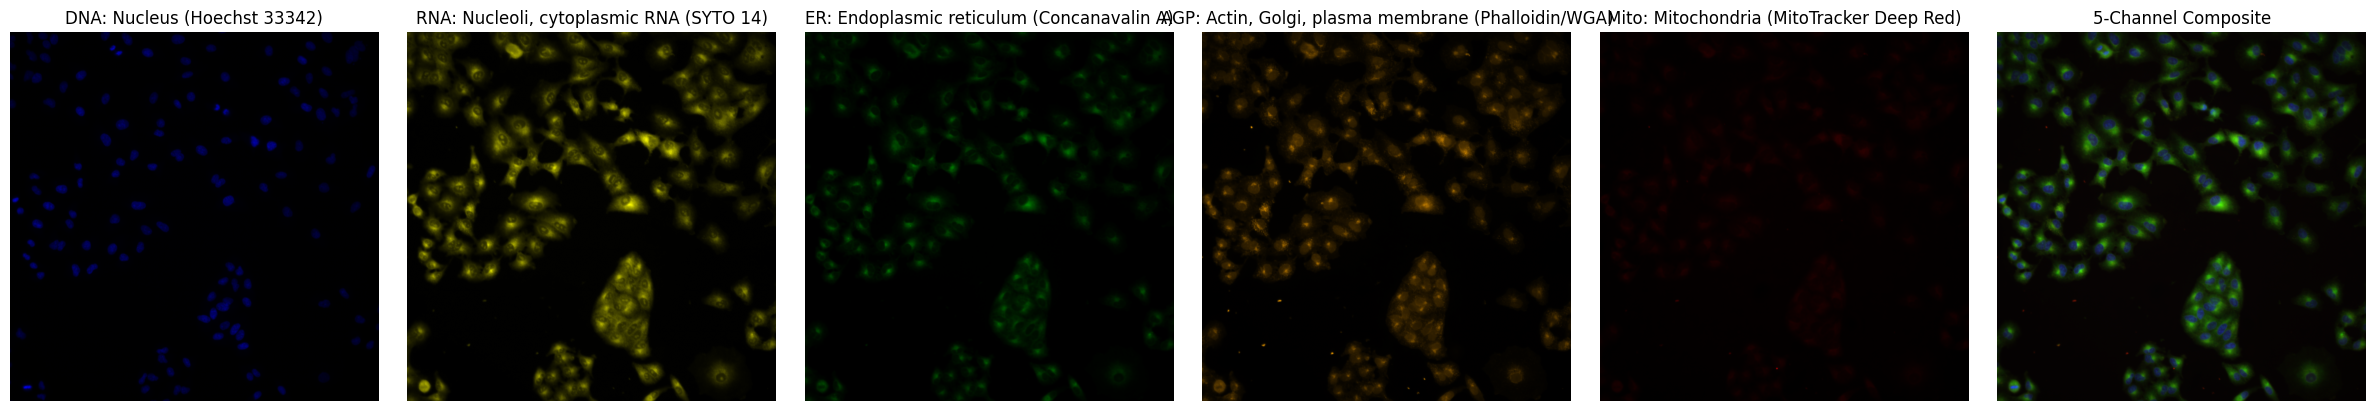

Processing sample 2/10: Well O11, Site 8


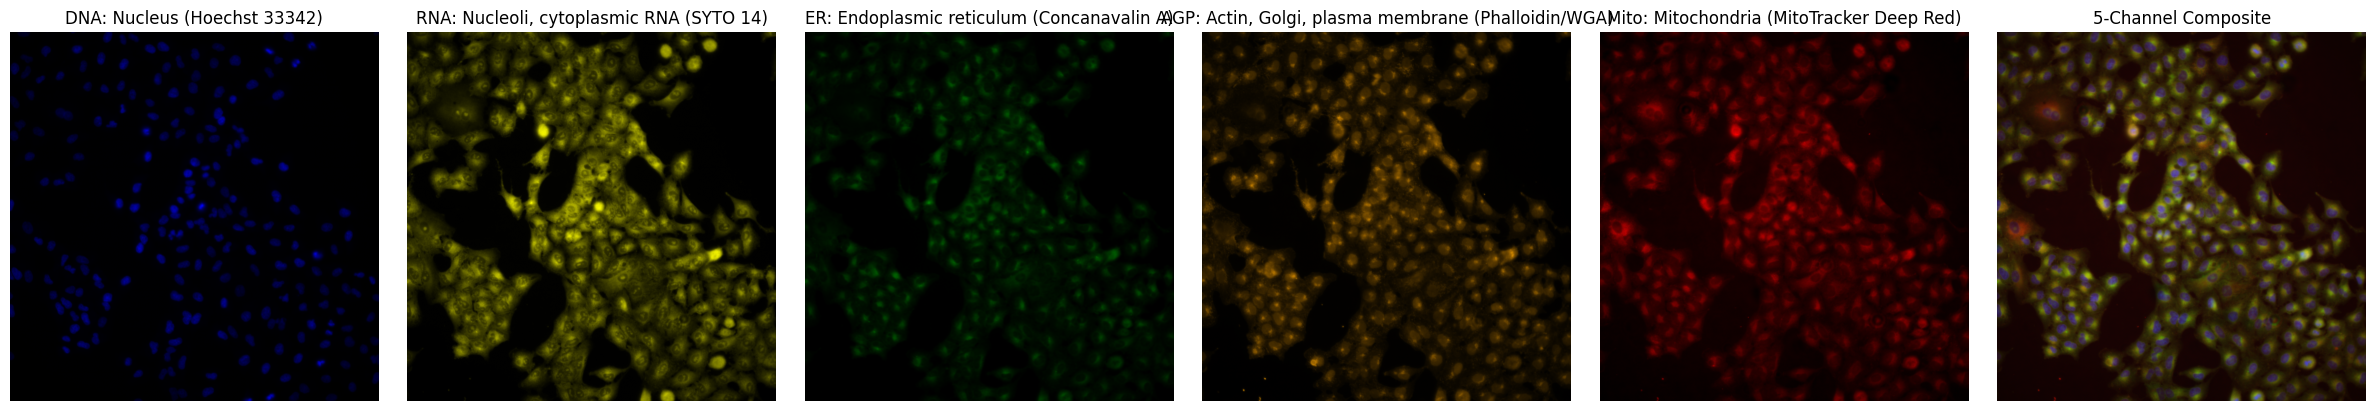

Processing sample 3/10: Well M21, Site 7


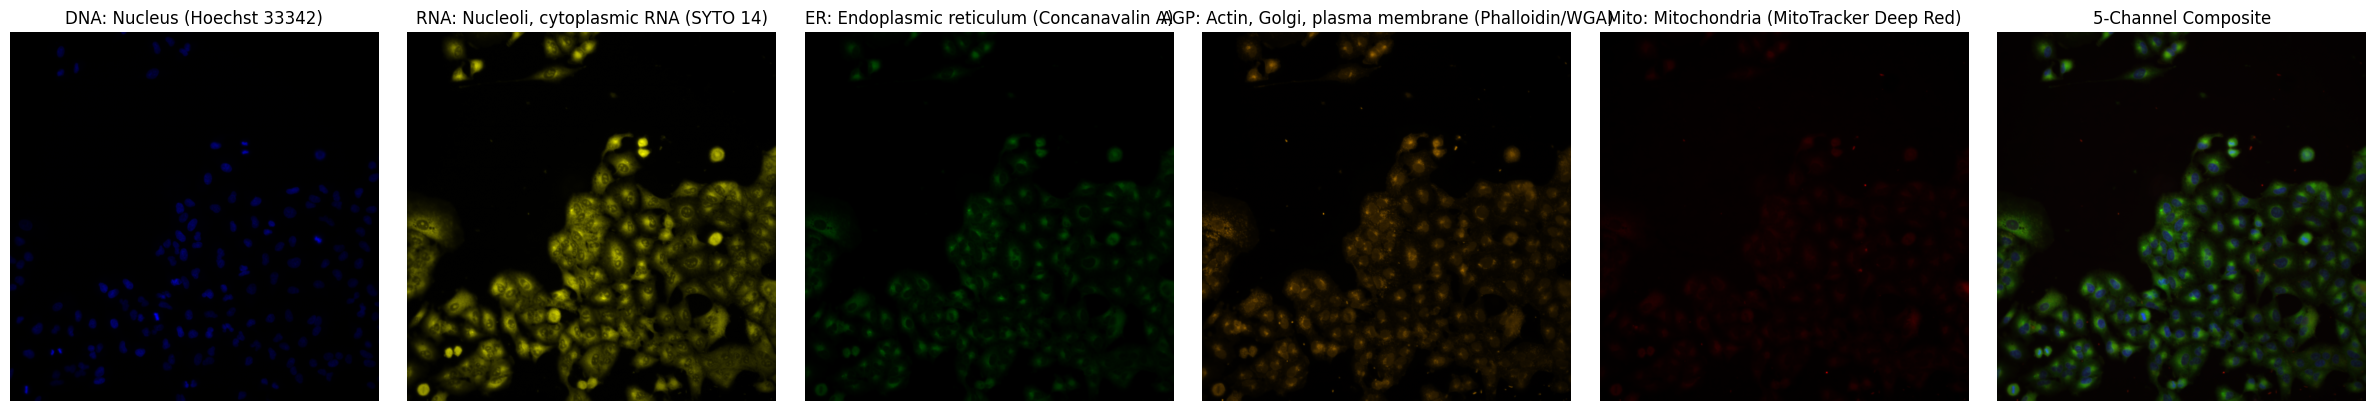

Processing sample 4/10: Well J19, Site 7


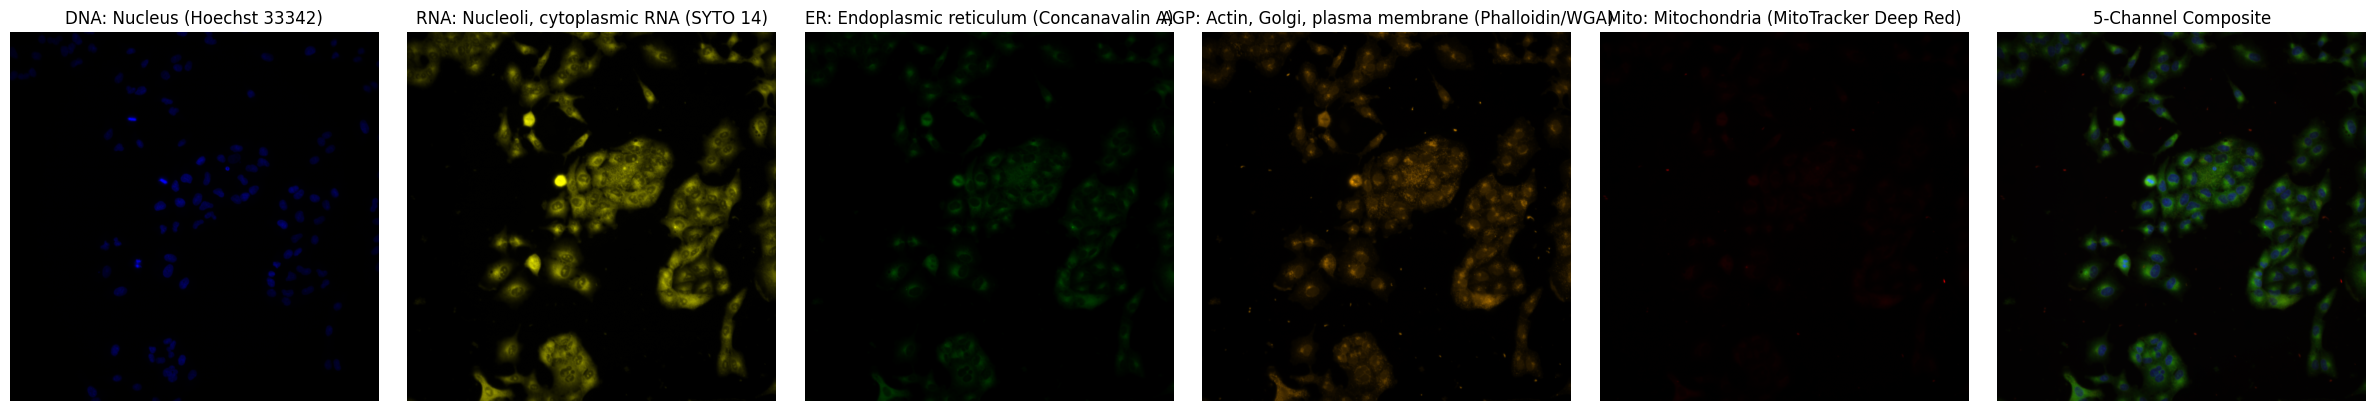

Processing sample 5/10: Well K11, Site 8


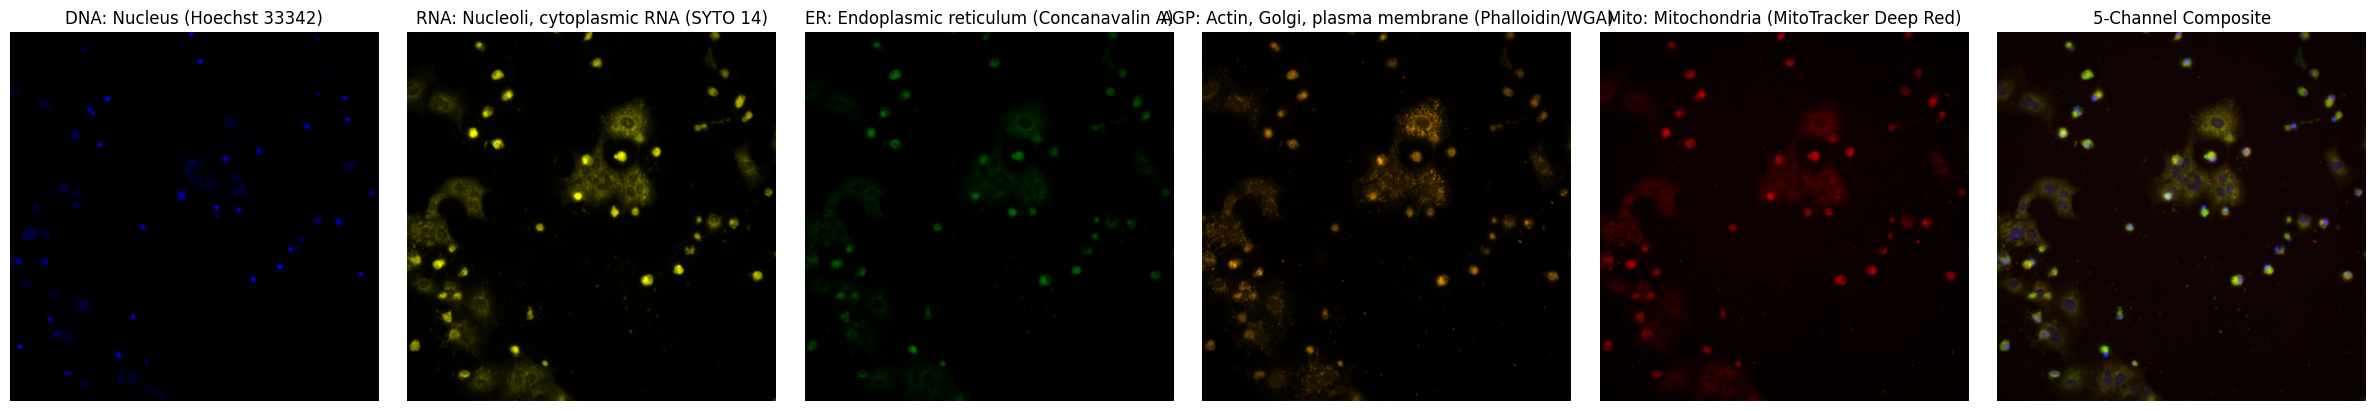

Processing sample 6/10: Well E04, Site 8


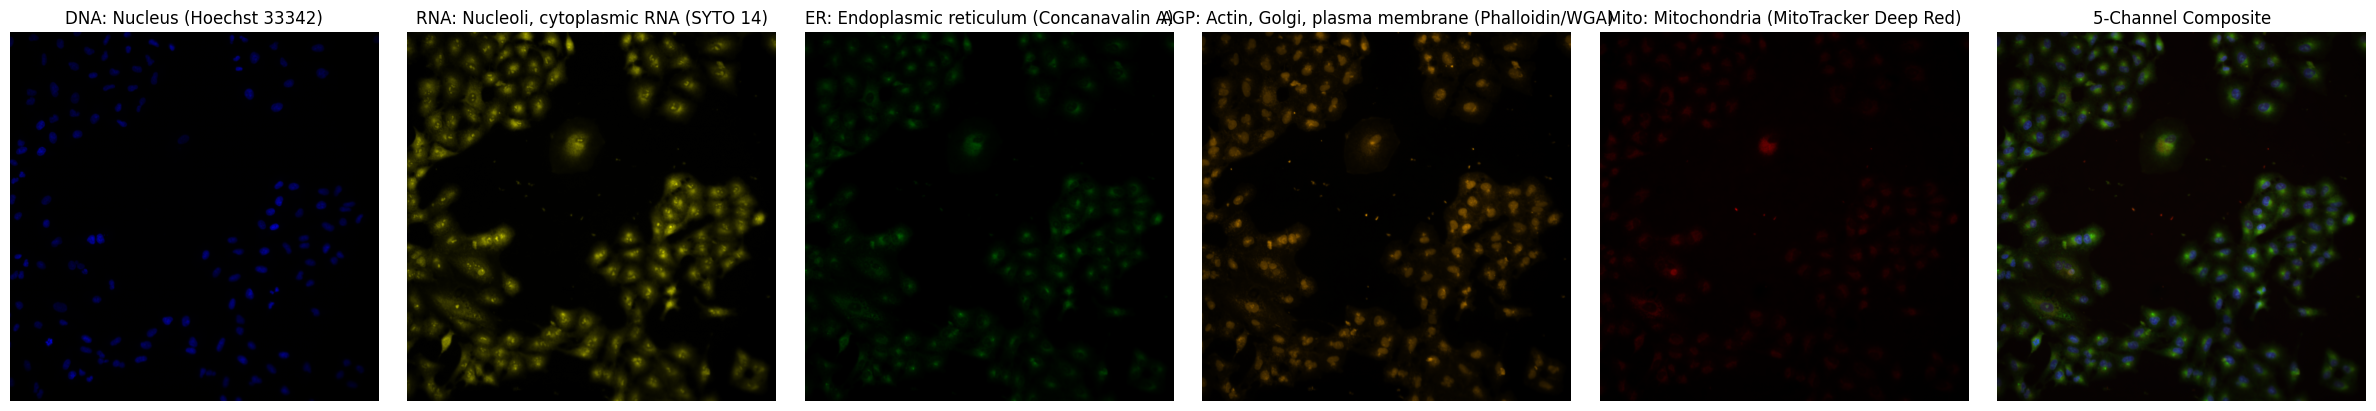

Processing sample 7/10: Well H03, Site 6


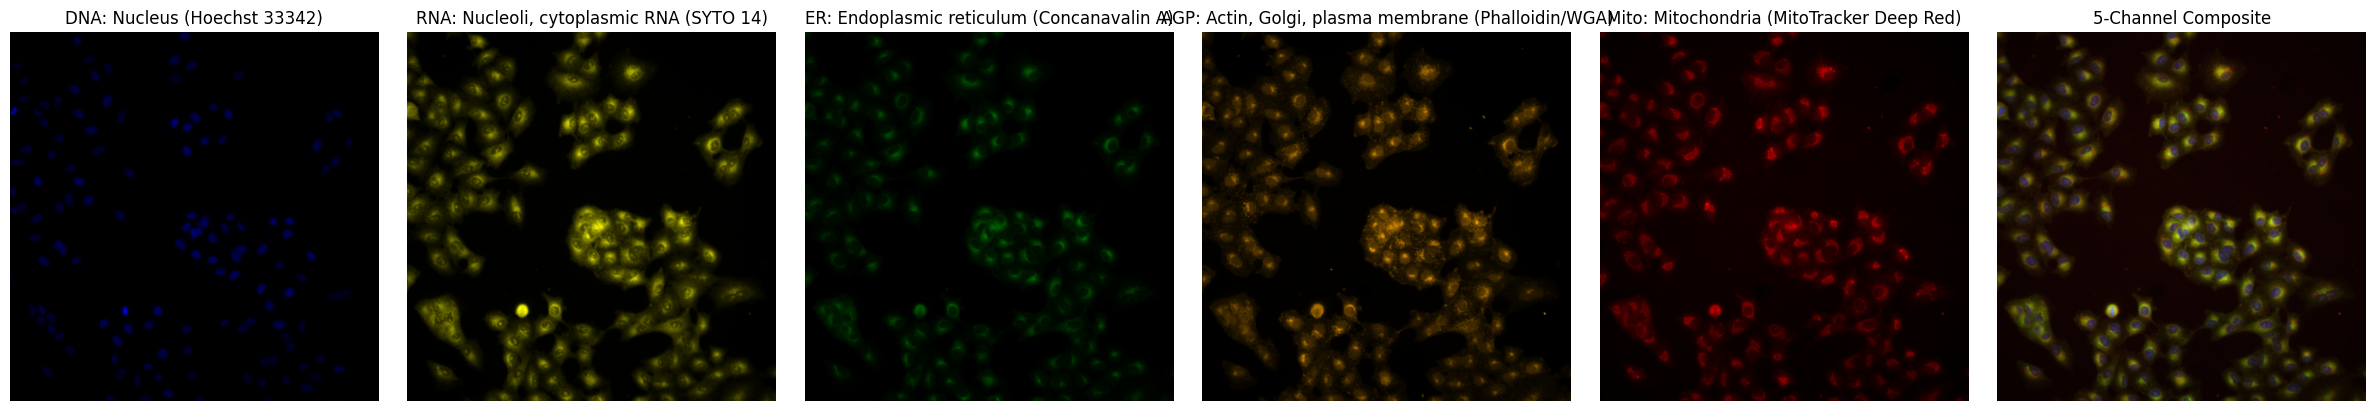

Processing sample 8/10: Well E02, Site 8


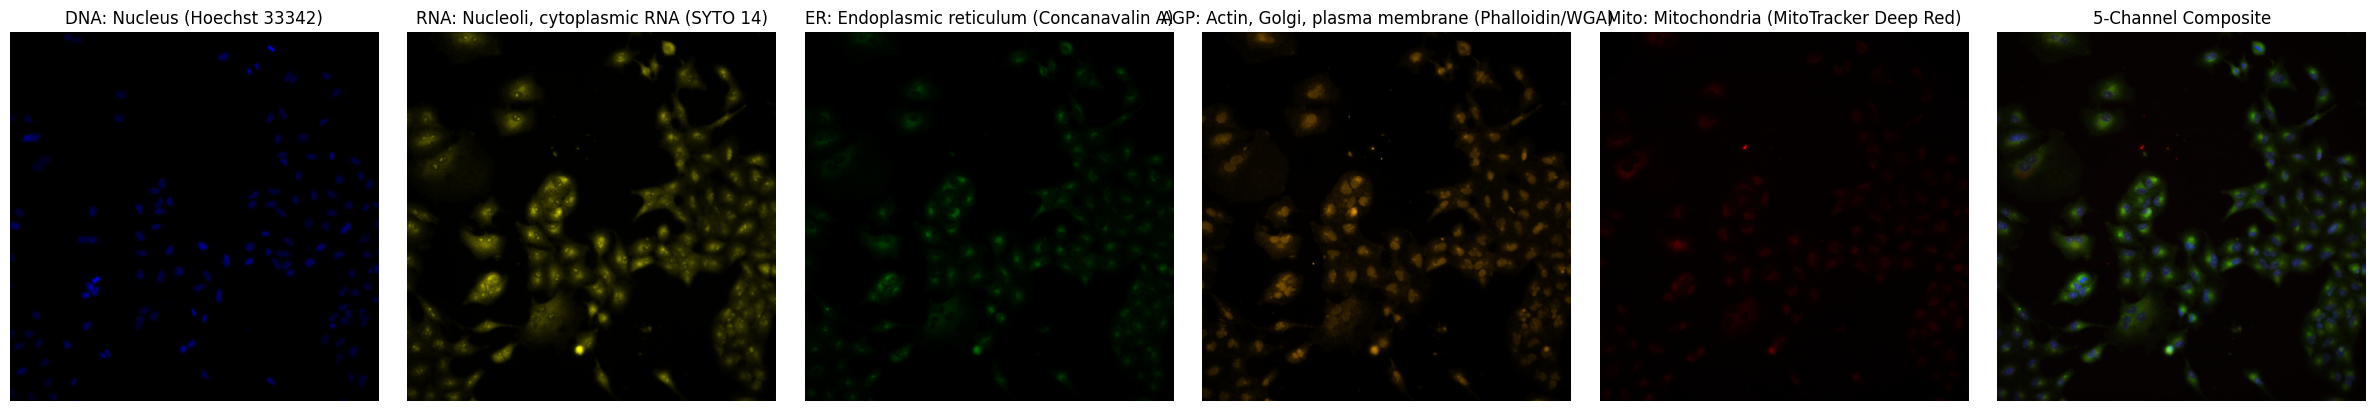

Processing sample 9/10: Well L06, Site 2


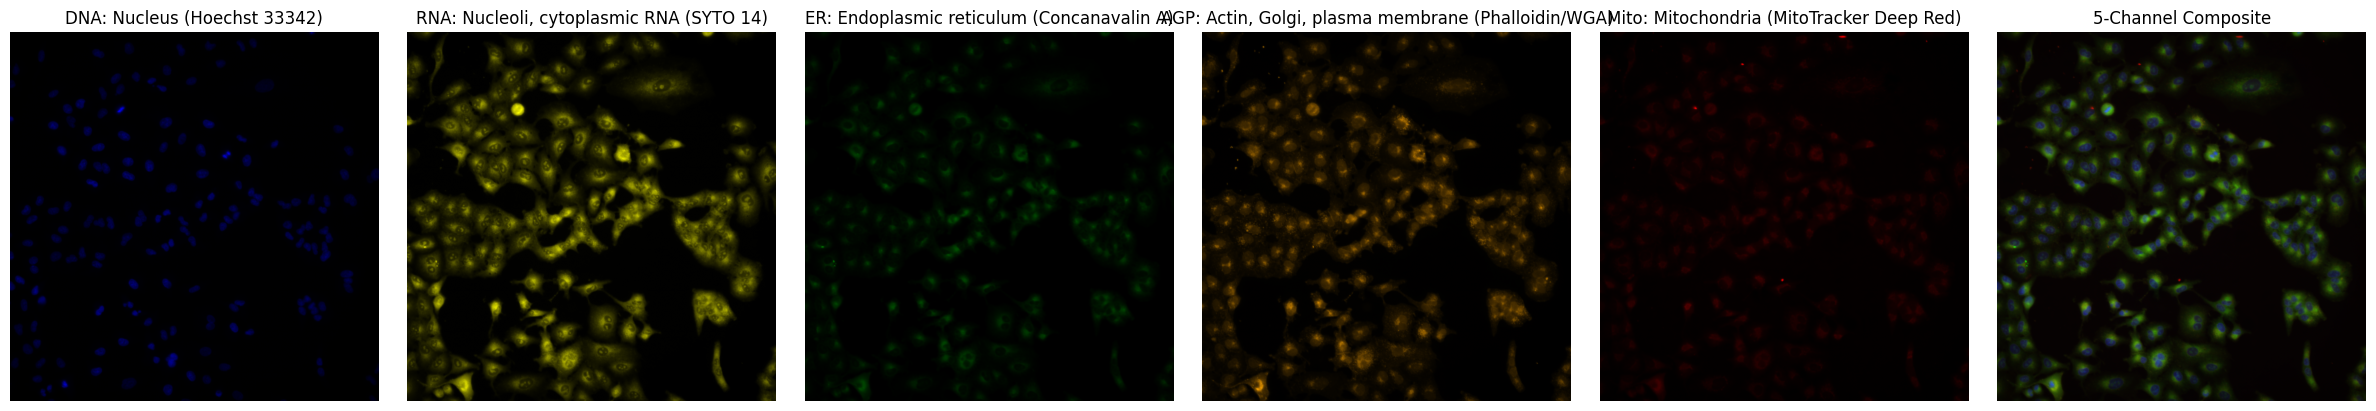

Processing sample 10/10: Well L21, Site 1


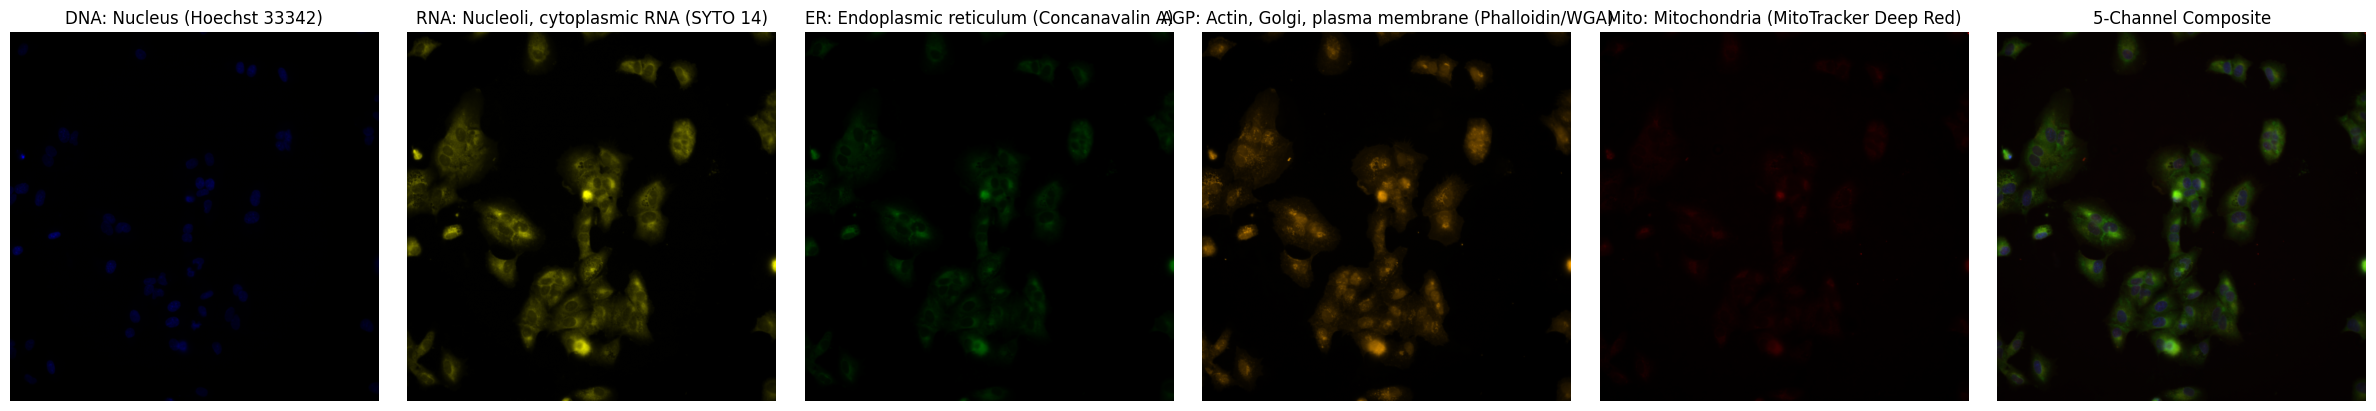

Dataset created with 10 images
 - Combined images saved to: microsplit_pilot_dataset/combined
 - DNA channel images saved to: microsplit_pilot_dataset/DNA
 - RNA channel images saved to: microsplit_pilot_dataset/RNA
 - ER channel images saved to: microsplit_pilot_dataset/ER
 - AGP channel images saved to: microsplit_pilot_dataset/AGP
 - Mito channel images saved to: microsplit_pilot_dataset/Mito
 - Metadata saved to: microsplit_pilot_dataset/metadata.csv

Dataset creation complete!


In [4]:
if __name__ == "__main__":
    print("Available batches:")
    for batch in BATCHES:
        plates = get_plates_in_batch(batch)
        print(f" - {batch}: {len(plates)} plates")
        if plates:
            print(f"   First plate: {plates[0]}")
    
    # Create dataset
    batch = "2020_11_04_CPJUMP1"  # First batch
    plate = get_plates_in_batch(batch)[0]  # First plate in the batch
    
    print(f"\nCreating dataset from batch {batch}, plate {plate}")
    experiment_info = create_microsplit_dataset(
        batch=batch,
        plate=plate,
        output_dir="microsplit_pilot_dataset",
        num_samples=10,
        channels_to_combine=[list(CHANNELS.keys())],  # All 5 channels
        normalize=False
    )
    
    print("\nDataset creation complete!")